# <center> TP4 : Reconnaissance de Formes </center>

### <center> Graphes, Convolution spectrale des graphes, et Appariement (Couplage)</center>



Au début de ce TP,  nous explorerons la convolution spectrale des graphes :

In [1]:
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from skimage.transform import AffineTransform, warp

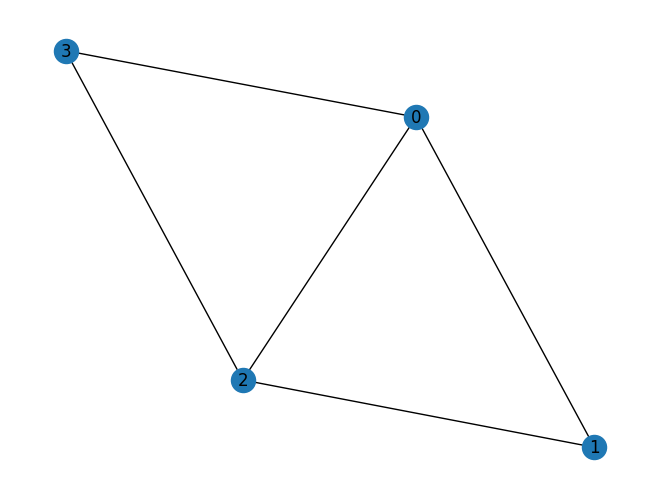

In [2]:
A = np.matrix([
    [0, 1, 1, 1],
    [1, 0, 1, 0], 
    [1, 1, 0, 1],
    [1, 0, 1, 0]],
    dtype=float
)

G = nx.from_numpy_array(A)
nx.draw(G, with_labels=True, arrows=True)
plt.show()

In [3]:
matrice = nx.to_numpy_array(G)
print(matrice)

[[0. 1. 1. 1.]
 [1. 0. 1. 0.]
 [1. 1. 0. 1.]
 [1. 0. 1. 0.]]


Pour l'aspect "spectral",, il suffit de comprendre qu'il s'agit simplement de décomposer un signal/audio/image/graphique en une combinaison (généralement, une somme) d'éléments simples (ondelettes, graphlets). 

Pour obtenir certaines propriétés intéressantes d'une telle décomposition, ces éléments simples sont généralement orthogonaux, c'est-à-dire mutuellement linéairement indépendants, et forment donc une base.

Lorsque nous parlons de "spectral" dans le traitement du signal/de l'image, nous faisons référence à la transformée de Fourier, qui nous offre une base particulière (matrice DFT, par exemple scipy.linalg.dft en Python) d'ondes sinusoïdales et cosinusoïdales élémentaires de différentes fréquences, de sorte que nous pouvons représenter notre signal/image comme une somme de ces ondes. 

Mais lorsque nous parlons de graphes et de réseaux neuronaux de graphes (GNN), le terme "spectral" implique une décomposition propre du laplacien du graphe L. Vous pouvez considérer le laplacien du graphe L comme une matrice d'adjacence A normalisée d'une manière particulière, tandis que la décomposition propre est un moyen de trouver ces composantes orthogonales élémentaires qui composent notre graphe.

Intuitivement, le laplacien du graphe montre dans quelles directions et avec quelle fluidité l'"énergie" se diffuse sur un graphe si nous plaçons un "potentiel" au nœud i. Un cas typique d'utilisation du laplacien en mathématiques et en physique est la résolution de la question de savoir comment un signal (une onde) se propage dans un système dynamique. La diffusion est régulière lorsqu'il n'y a pas de changements soudains de valeurs entre les voisins.

[[3. 0. 0. 0.]
 [0. 2. 0. 0.]
 [0. 0. 3. 0.]
 [0. 0. 0. 2.]]
[[ 3. -1. -1. -1.]
 [-1.  2. -1.  0.]
 [-1. -1.  3. -1.]
 [-1.  0. -1.  2.]]


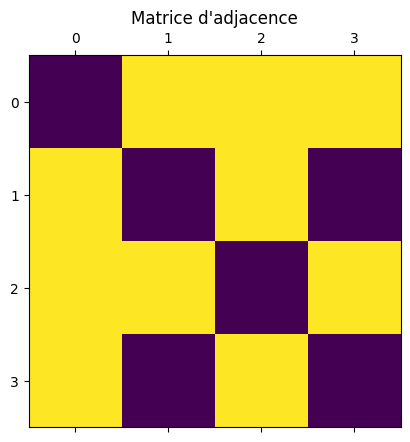

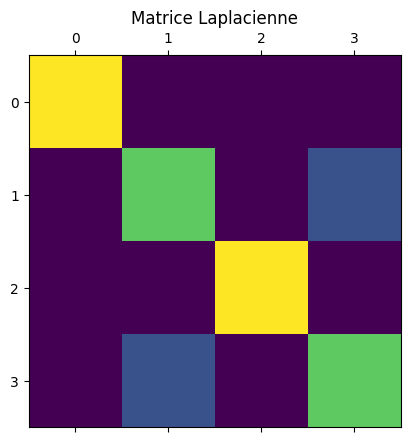

In [4]:
# A est la matrice d'adjacence et D est la matrice diagonale des degrés.
# A compléter ..
# ...
# ...
deg = np.sum(A, axis=1)  
D =  np.diagflat(deg)
print(D)

# Matrice Laplacienne

# A compléter ..
L = D - A
print(L)

# Affichage des matrices

# A compléter ..
# ...
# ...
plt.matshow(A)
plt.title("Matrice d'adjacence")
plt.matshow(L)
plt.title("Matrice Laplacienne")
plt.show()


#### Laplacien normalisé : pour éviter des valeurs explosant avec des multiplications.

$L_{\text{norm}} = I - D^{-1/2} A D^{-1/2}$

[[ 1.         -0.40824829 -0.33333333 -0.40824829]
 [-0.40824829  1.         -0.40824829  0.        ]
 [-0.33333333 -0.40824829  1.         -0.40824829]
 [-0.40824829  0.         -0.40824829  1.        ]]


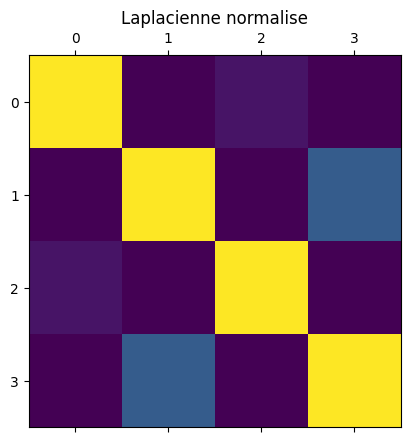

[[ 1.         -0.40824829 -0.33333333 -0.40824829]
 [-0.40824829  1.         -0.40824829 -0.        ]
 [-0.33333333 -0.40824829  1.         -0.40824829]
 [-0.40824829 -0.         -0.40824829  1.        ]]


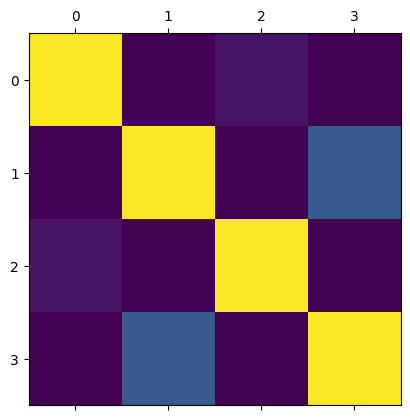

[[ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]]


In [5]:
# Calcul des valeurs propres et vecteurs propres de la matrice Laplacienne
# A compléter ..
# ...

Lnorm = np.identity(L.shape[0]) - np.sqrt(np.linalg.inv(D)) @ A @ np.sqrt(np.linalg.inv(D))
print(Lnorm)
plt.matshow(Lnorm)
plt.title("Laplacienne normalise")
plt.show()

from scipy.sparse.csgraph import laplacian

# A comparer  avec le résultat de laplacian de scipy.sparse.csgraph
# A compléter ..
# ...
Lscipy = laplacian(A, normed=True)
print(Lscipy)
plt.matshow(Lscipy)
plt.show()

print(np.isclose(Lnorm, Lscipy))


In [ ]:
# lambdas, vectors = np.linalg.eig(L)

### Graphe biparti

#### Une première construction du graphe

A partir de l’ensemble des points d’intérêts et des descripteurs définis au TP précédent, créez un graphe biparti entre deux images où chaque noeud de l'image 1 est connecté à un noeud de l'image 2 avec le coût minimal.


In [6]:
def detecter_points_interets(image):
    gris = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    corners = cv2.goodFeaturesToTrack(gris, 10, 0.01, 15)
    corners = np.intp(corners)
    kp_list = [cv2.KeyPoint(float(x), float(y), 3) for x, y in corners[:, 0]]

    image1_copy = image.copy()

    for i in corners:
        x, y = i.ravel()
        cv2.circle(image1_copy, (x, y), 3, (255, 0, 0), 1)

    # plt.imshow(image1_copy)
    # plt.show()

    return kp_list, image1_copy

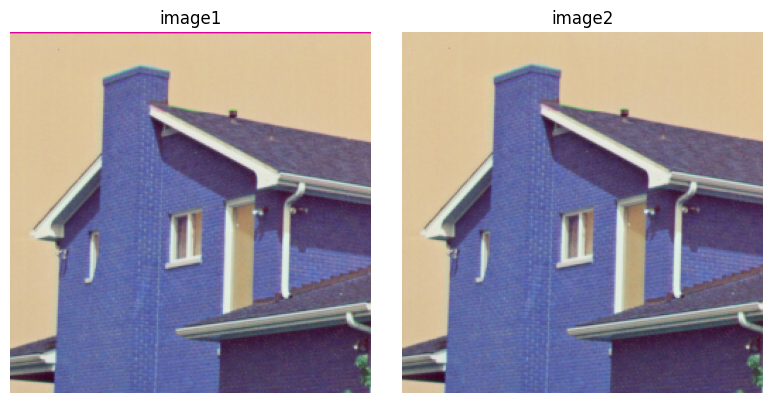

[< cv2.KeyPoint 000001CA92663060>, < cv2.KeyPoint 000001CA9264FCF0>, < cv2.KeyPoint 000001CA94763210>, < cv2.KeyPoint 000001CA94762D60>, < cv2.KeyPoint 000001CA947614D0>, < cv2.KeyPoint 000001CA94763870>, < cv2.KeyPoint 000001CA94761DA0>, < cv2.KeyPoint 000001CA947638D0>, < cv2.KeyPoint 000001CA94762E80>, < cv2.KeyPoint 000001CA947635A0>]
[< cv2.KeyPoint 000001CAF2F54270>, < cv2.KeyPoint 000001CA948F18C0>, < cv2.KeyPoint 000001CA948F18F0>, < cv2.KeyPoint 000001CA948F1920>, < cv2.KeyPoint 000001CA948F19B0>, < cv2.KeyPoint 000001CA948F19E0>, < cv2.KeyPoint 000001CA948F1A10>, < cv2.KeyPoint 000001CA948F1A40>, < cv2.KeyPoint 000001CA948F1A70>, < cv2.KeyPoint 000001CA948F1AA0>]


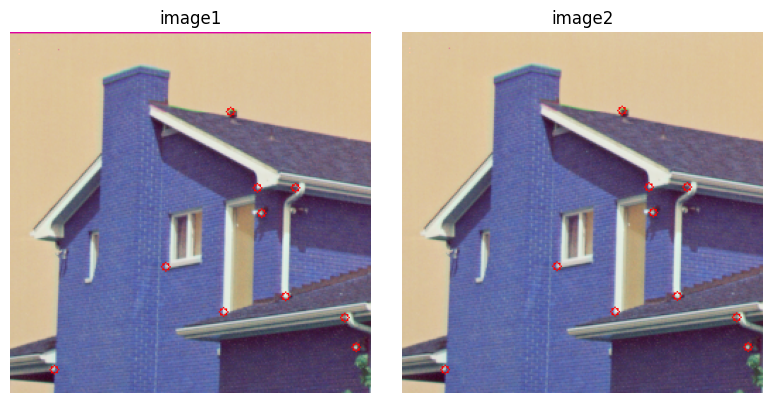

In [7]:
image1 = cv2.imread('images/house1.ppm')
image2 = cv2.imread('images/house2.ppm')

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("image1")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("image2")
plt.axis('off')

plt.tight_layout() 
plt.show()

list1, im1 = detecter_points_interets(image1)
list2, im2 = detecter_points_interets(image2)
print(list1)
print(list2)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(im1)
plt.title("image1")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(im2)
plt.title("image2")
plt.axis('off')

plt.tight_layout() 
plt.show()


In [8]:
# Reprenez les fonctions du TP précédent  : extraction de decripteurs, ...


def matching(image1, image2, kp_list1, kp_list2):
    # A compléter ..
    # ...
    correspondances = []
    for i, kp1 in enumerate(kp_list1):
        x1, y1 = np.intp(kp1.pt)
        distance_minimal = float("inf")
        index_correspondance = -1

        for j, kp2 in enumerate(kp_list2):
            x2, y2 = np.intp(kp2.pt)
            distance = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
            similarite = np.sum(np.square(image1[y1, x1] - image2[y2, x2]))

            distance += similarite
            if distance < distance_minimal:
                distance_minimal = distance
                index_correspondance = j

        correspondances.append((i, index_correspondance, similarite))

    return correspondances

In [9]:
def trace(img1, img2, kp_list1, kp_list2, correspondances):
    hauteur, largeur = img1.shape[:2]
    img2_resized = cv2.resize(img2, (largeur, hauteur))
    img1_croix = img1.copy()
    img2_croix = img2_resized.copy()
    for correspondance in correspondances:
        x1, y1 = kp_list1[correspondance[0]].pt
        x2, y2 = kp_list2[correspondance[1]].pt
        img1_croix = cv2.drawMarker(img1_croix, (int(x1), int(y1)), (0,0,255), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        img2_croix = cv2.drawMarker(img2_croix, (int(x2), int(y2)), (0,0,255), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
    img_combinee = np.hstack((img1_croix, img2_croix.copy()))
    for correspondance in correspondances:
        x1, y1 = kp_list1[correspondance[0]].pt
        x2, y2 = kp_list2[correspondance[1]].pt
        img_combinee = cv2.line(img_combinee, (int(x1), int(y1)), (int(x2) + largeur, int(y2)), (255, 0, 0), 1)

    plt.imshow(cv2.cvtColor(img_combinee, cv2.COLOR_BGR2RGB))
    plt.title("Appariement de points d'interet entre les deux images")
    plt.axis('off')
    plt.show()

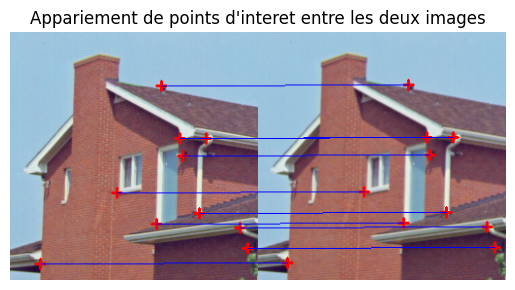

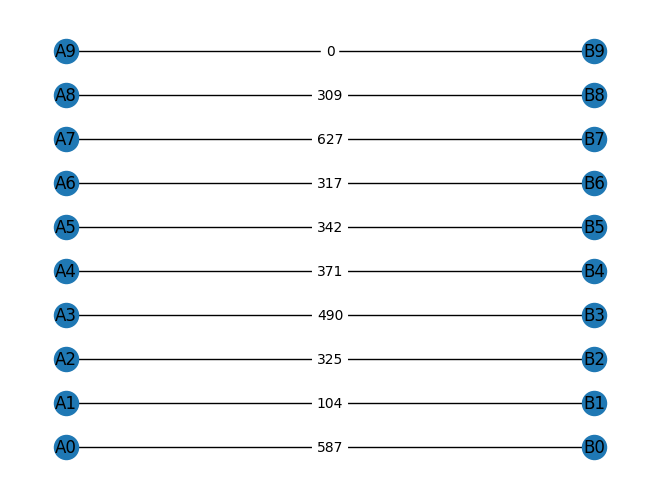

In [10]:

# Charger les images
image1 = cv2.imread('images/house1.ppm')
image2 = cv2.imread('images/house2.ppm')

## Detecter les points d'interet sur les images
kp_list1, _ = detecter_points_interets(image1)
kp_list2, _ = detecter_points_interets(image2)

# Trouver les correspondances entre les deux ensembles de points clés
correspondances = matching(image1, image2, kp_list1, kp_list2)
trace(image1,image2,kp_list1,kp_list2,correspondances)


# Création d'un graphe biparti avec poids sur les arêtes
G = nx.Graph()

# Ajout des sommets dans les ensembles correspondants avec bipartite=0 pour le premier ensemble et bipartite=1 pour le second ensemble 
# Ajout des sommets dans le premier ensemble
# A compléter ..
# ...
for i in range(len(kp_list1)):
    G.add_node(f"A{i}", bipartite=0)

for j in range(len(kp_list2)):
    G.add_node(f"B{j}", bipartite=1)



# Ajout des arêtes entre les ensembles basées sur les correspondances
# A compléter ..
# ...
for correspondance in correspondances:
    i, j, poids = correspondance
    G.add_edge(f"A{i}", f"B{j}", weight=poids)

# Ajout des arêtes avec poids entre les ensembles basées sur les correspondances
# A compléter ..
# ...





# Affichage du graphe biparti avec poids sur les arêtes et espacement global ==> nx.bipartite_layout + nx.draw  + nx.draw_networkx_edge_labels ..
# A compléter ..
# ...

pos = nx.bipartite_layout(G, nodes=[n for n, d in G.nodes(data=True) if d['bipartite']==0])
nx.draw(G, pos, with_labels=True)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()




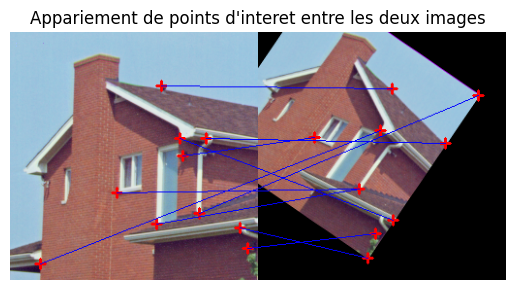

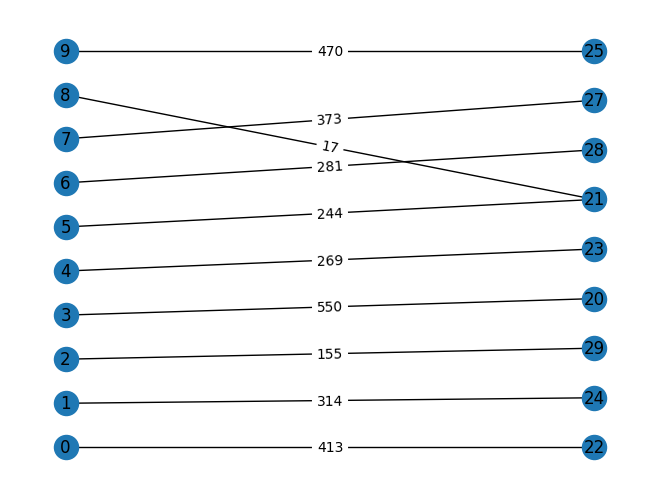

In [11]:
# Charger les images
image1 = cv2.imread('images/house1.ppm')
kp_list1, _ = detecter_points_interets(image1)



# Transformation de l'image pour le matching : Translation, Rotation, Scaling ==> image2 avec warp
# A compléter ..

image2 = cv2.imread('images/house2.ppm')
# image2_rotate = cv2.getRotationMatrix2D((image2.shape[1]//2, image2.shape[0]//2), -15, 0.8)
# image2_w = cv2.warpAffine(image2, image2_rotate, (image2.shape[1], image2.shape[0]))
tform = AffineTransform(scale = (0.8, 0.8), rotation=0.6, translation=(60, -50))
image1_w = (warp(image1, tform.inverse, output_shape=image1.shape[:2]) * 255).astype(np.uint8)
kp_list2, _ = detecter_points_interets(image1_w)

# A compléter ..    
# ...

correspondances = matching(image1, image1_w, kp_list1, kp_list2)
trace(image1,image1_w,kp_list1,kp_list2,correspondances)


G = nx.Graph()
G.add_nodes_from(range(len(kp_list1)), bipartite=0)
G.add_nodes_from(range(len(kp_list2)), bipartite=1)

correspondances1 = [(x, y + 20, z) for x, y, z in correspondances]
G.add_weighted_edges_from(correspondances1)

# for node, d in G.nodes(data=True):
#     print(node)
#     print((d['bipartite']))

pos = nx.bipartite_layout(G,range(len(kp_list1)))
pos = {node: (x, y * 2.5) for node, (x, y) in pos.items()}
nx.draw(G, pos, with_labels=True)
edge_labels = nx.get_edge_attributes(G, 'weight')
# ou: edges_labels = {(i, j): f"{weight:.2f}" for i, j, weight in G.edges.data('weight')}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

In [12]:
correspondances

[(0, 2, np.uint64(413)),
 (1, 4, np.uint64(314)),
 (2, 9, np.uint64(155)),
 (3, 0, np.uint64(550)),
 (4, 3, np.uint64(269)),
 (5, 1, np.uint64(244)),
 (6, 8, np.uint64(281)),
 (7, 7, np.uint64(373)),
 (8, 1, np.uint64(17)),
 (9, 5, np.uint64(470))]

#### Une seconde construction du graphe


A partir de l’ensemble des points d’intérêts et des descripteurs définis au TP précédent, créez un graphe où chaque sommet représente un point d’intérêt et une arête (i, j) existe entre les points i et j si j est un des 5 plus proche voisin de i et vice versa.

La distance considérée pour cette construction est la distance spatiale entre les coordonnées des points.


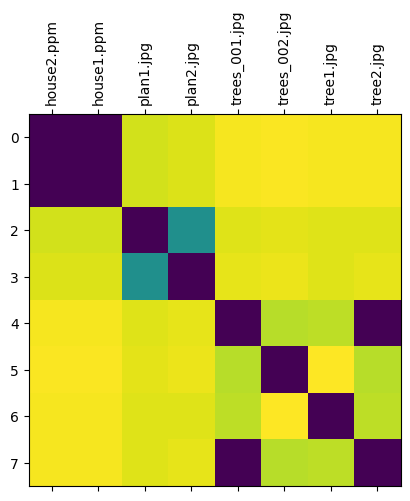

In [13]:
import os 

def createGraph(ptDesc):
    # kp=ptDesc['kp']
    kp=ptDesc[1]
    coords=[kp[i].pt for i in range(len(kp))]

    bf=cv2.BFMatcher()
    matches =bf.knnMatch(np.asarray(coords,np.float32),np.asarray(coords,np.float32),6)
    train=[[(k.trainIdx,k.distance) for k in matches[i]] for i in range(len(matches))]
    mutualMatch=[ [ k for k in train[i] if k[0]!= i and i in [ l[0] for l in train[k[0]]]] for i in range(len(matches))]

    G=nx.Graph()
    G.add_nodes_from(range(len(kp)))

    for i in range(len(matches)):
        print(mutualMatch[i])
        # correspondances1 = [(x, y + 20, z) for x, y, z in mutualMatch]
        # G.add_weighted_edges_from(correspondances1)
        
    return G
    
# Créer un graphe à partir de la première image de la liste
# Dessiner le graphe correspondant en utilisant la librairie NetworkX :  nx.from_numpy_array et nx.draw
# A compléter ..
# ...



def creer_dictionnaire(nom, orb, orb_detect):
    #A compléter
    #...
    img = cv2.imread(nom)
    if (orb_detect):
        kp = orb.detect(img, None)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        corners = cv2.goodFeaturesToTrack(gray, 50, 0.01, 15)
        corners = np.intp(corners)
        kp = [cv2.KeyPoint(float(x), float(y), 3) for x, y in corners[:, 0]]

    kp, desc = orb.compute(img, kp)

    return {'nom': nom, 'kp': kp, 'desc': desc, 'img': img}


def cout_alignement(desc1, desc2):
    distance = [[cv2.norm(p, q, cv2.NORM_HAMMING) for p in desc1] for q in desc2]
    return np.asarray(distance)


def dist_pts_interet(pt_desc1, pt_desc2):      
    distance = cout_alignement(pt_desc1['desc'], pt_desc2['desc'])
    
    from scipy.optimize import linear_sum_assignment
    row_ind, col_ind = linear_sum_assignment(distance)
    cout = np.asarray([distance[row_ind[i]][col_ind[i]] for i in range(len(row_ind))]).sum()
    
    return cout, row_ind, col_ind


def charger_noms(fichier):
    noms = []
    with open(fichier, "r") as f:
        noms = f.readlines()
    noms = [nom[:-1] for nom in noms]
    return noms


def afficher(distance, noms):
    nb = distance.shape[0]
    # A compléter
    #...
    plt.matshow(distance)
    plt.xticks(ticks=np.arange(nb), labels=noms, rotation=90)


    plt.show()




##Créer un détecteur (orb) avec les paramètres par défaut
orb = cv2.ORB_create(edgeThreshold=0, nfeatures=50)

## Chergement des imagaes à partir dea list.txt
files = charger_noms('list.txt')

## Create PtDesc list
PtDesc = [creer_dictionnaire(name, orb, False) for name in files]

## Calculer les distances
nb = len(files)
distances = np.asarray([[dist_pts_interet(PtDesc[i], PtDesc[j])[0] for i in range(nb)] for j in range(nb)])

## Extract base names from paths
names = [os.path.basename(file) for file in files]

## afficher les résultats
afficher(distances, names)


# Ajout des arêtes entre les ensembles basées sur les correspondances


In [15]:
def createGraph(ptDesc):
    # kp=ptDesc['kp']
    kp = [ ptDesc[i]['kp'] for i in range(len(ptDesc)) ]
    # coords=[kp[i].pt for i in range(len(kp))]
    coords=[kp[:][0][i].pt for i in range(len(kp))]

    bf=cv2.BFMatcher()
    matches =bf.knnMatch(np.asarray(coords,np.float32),np.asarray(coords,np.float32),6)
    train=[[(k.trainIdx,k.distance) for k in matches[i]] for i in range(len(matches))]
    mutualMatch=[ [ k for k in train[i] if k[0]!= i and i in [ l[0] for l in train[k[0]]]] for i in range(len(matches))]

    G=nx.Graph()
    G.add_nodes_from(range(len(kp)))

    for i in range(len(matches)):
        for match in mutualMatch[i]:
            G.add_edge(i, match[0], weight=match[1])

        
    return G

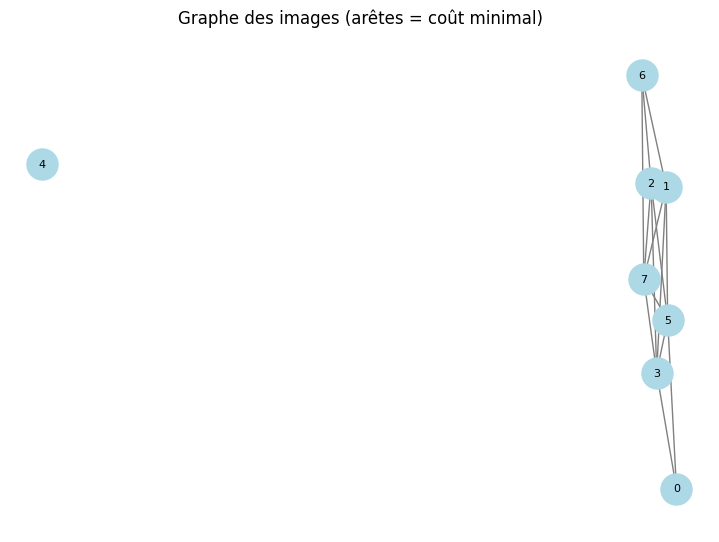

In [16]:
import numpy as np
import networkx as nx
from typing import Dict, Any, Optional
import os 
import cv2
import matplotlib.pyplot as plt


def Affiche_Graphe(Gimg, titre="Graphe des images (arêtes = coût minimal)"):
    plt.figure(figsize=(7, 5))
    # A compléter ...
    # ...
    pos = nx.spring_layout(Gimg)
    nx.draw(Gimg, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=8)
    plt.title(titre)
    plt.axis("off")
    plt.show()

PtDesc = np.array([creer_dictionnaire(name, orb, False) for name in files])

# Construire et afficher le graphe des images
G = createGraph(PtDesc)
Affiche_Graphe(G)
#show_image_graph_draggable(G)

Step 0: [0, np.int64(3)]


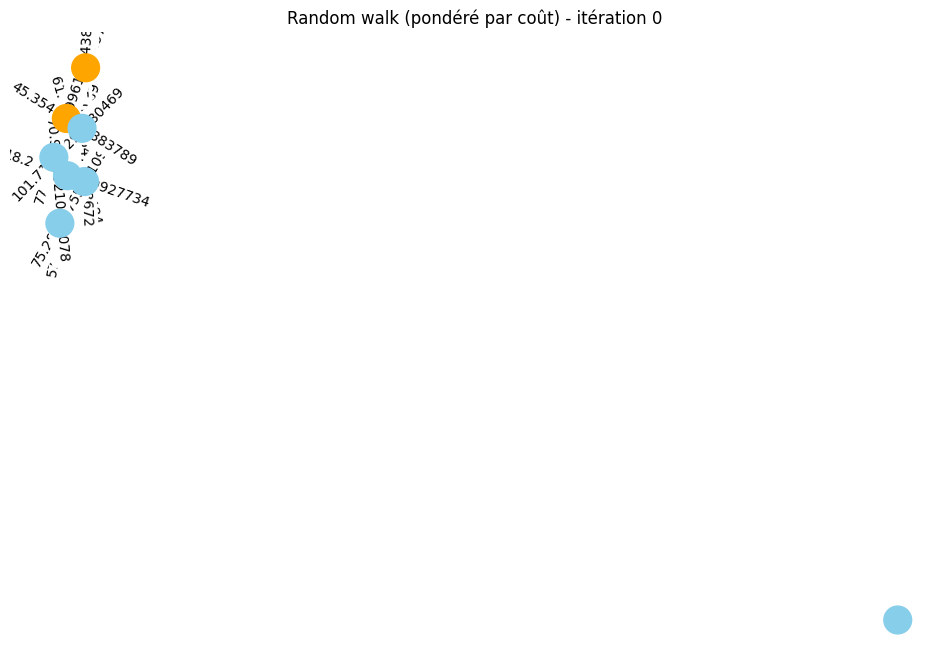

Step 1: [0, np.int64(3), np.int64(5)]


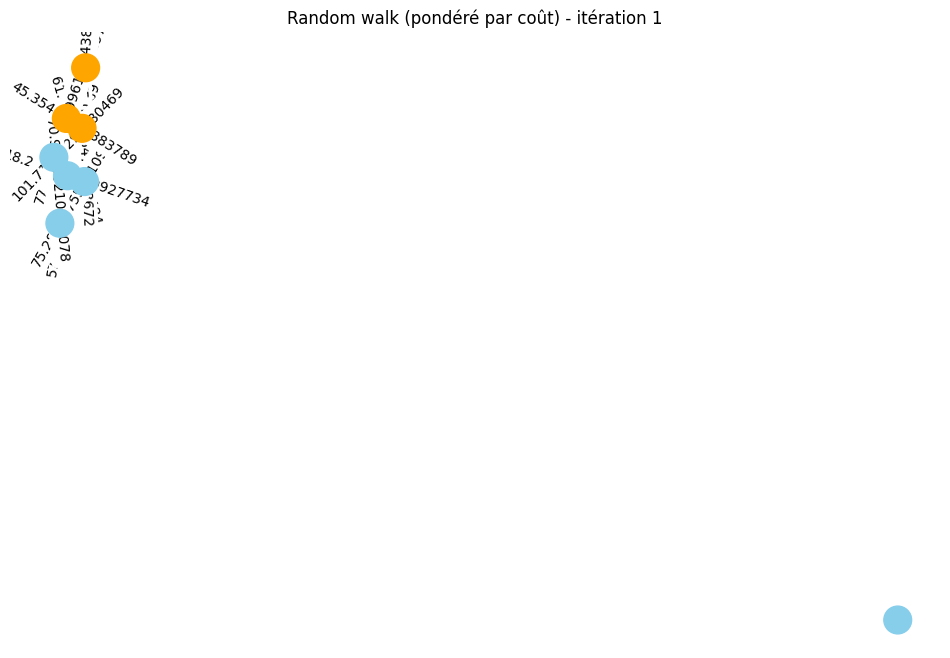

Step 2: [0, np.int64(3), np.int64(5), np.int64(2)]


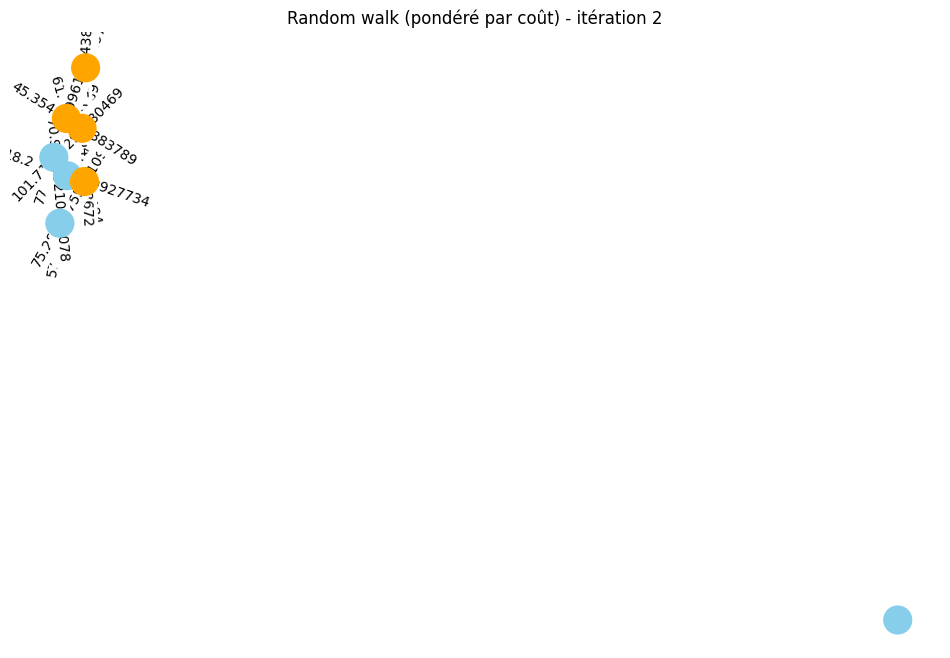

Step 3: [0, np.int64(3), np.int64(5), np.int64(2), np.int64(1)]


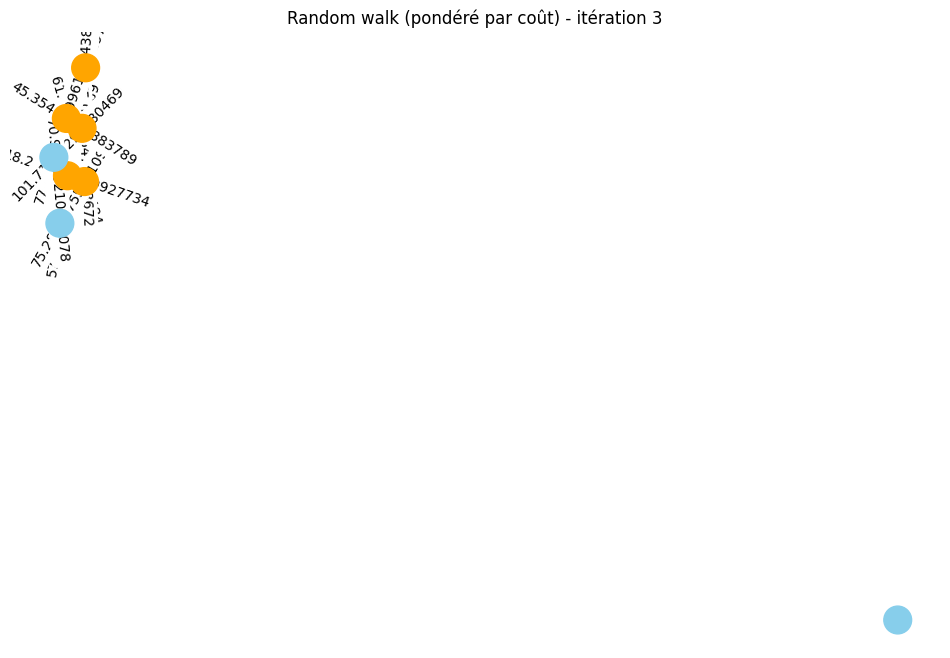

Step 4: [0, np.int64(3), np.int64(5), np.int64(2), np.int64(1), np.int64(7)]


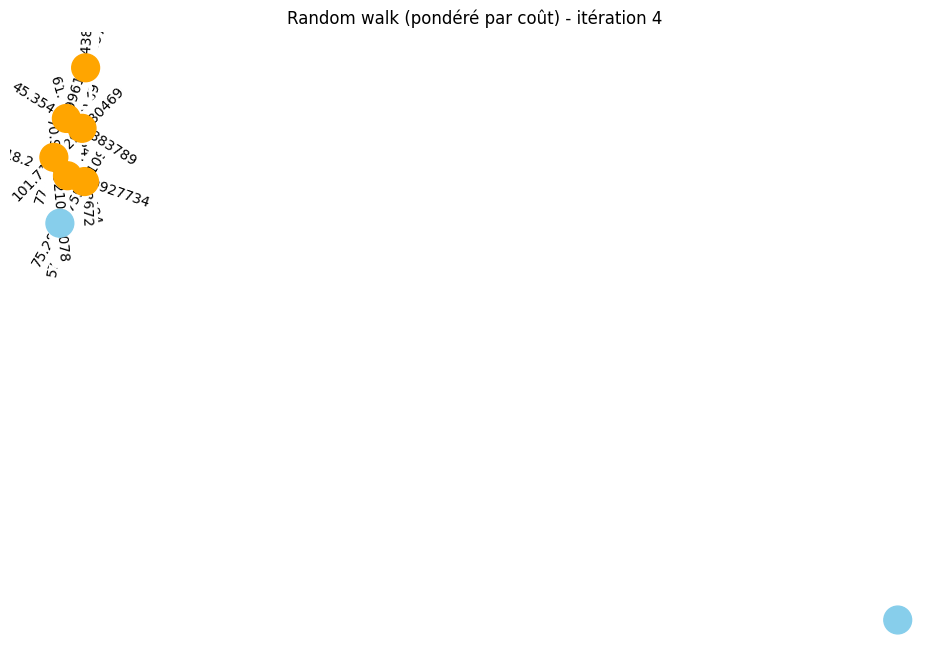

Step 5: [0, np.int64(3), np.int64(5), np.int64(2), np.int64(1), np.int64(7), np.int64(6)]


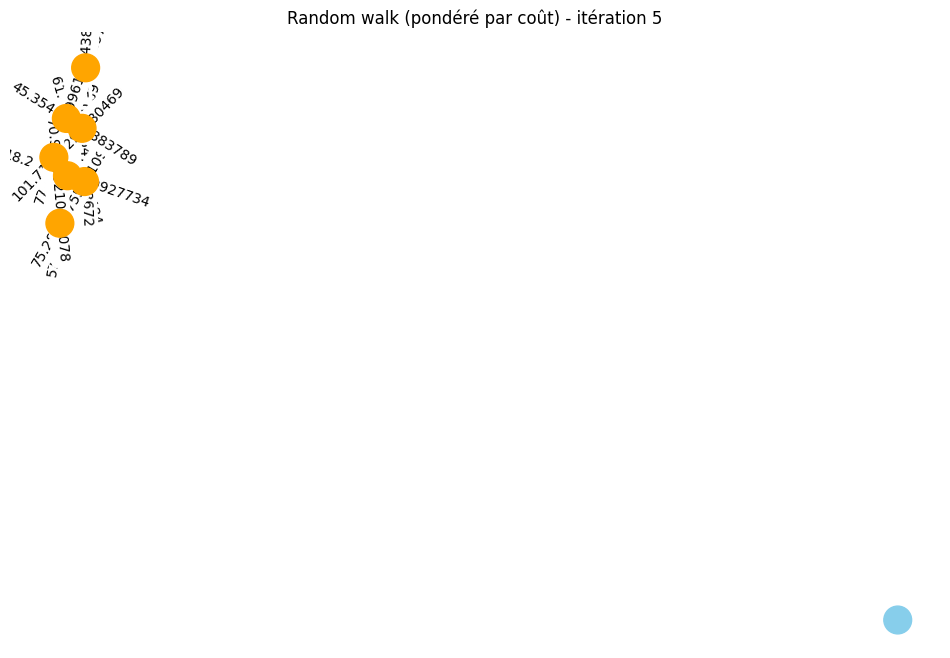

In [20]:
import matplotlib.pyplot as plt
import networkx as nx

def show_walk(G, path, pos=None, iter=0, label=False, title="Random walk (pondéré par coût)"):
    """
    Affiche un graphe avec le chemin `path` mis en évidence.                        
    Paramètres
    ----------
    G : networkx.Graph
        Graphe à afficher.                  
    path : list
        Liste des nœuds représentant le chemin à mettre en évidence.
    pos : dict, optional
        Dictionnaire des positions des nœuds pour l'affichage.               
    iter : int, optional
        Numéro de l'itération (utilisé pour l'affichage des coûts sur les arêtes).
    label : bool, optional
        Si True, affiche les labels des nœuds (noms des images si disponibles).
    title : str, optional
        Titre du graphique.
    """
    # A compléter ...
    # ...
    if pos is None:
        pos = nx.spring_layout(G, seed=0)
    
    plt.figure(figsize=(12, 8))
    
    edge_colors = []
    for u, v in G.edges():
        if u in path and v in path and abs(path.index(u) - path.index(v)) == 1:
            edge_colors.append('red')
        else:
            edge_colors.append('gray')
    
    edge_widths = []
    for u, v in G.edges():
        if u in path and v in path and abs(path.index(u) - path.index(v)) == 1:
            edge_widths.append(2.5)
        else:
            edge_widths.append(1.0)

    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths)
    
    node_colors = ['orange' if n in path else 'skyblue' for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400)
    
    if label:
        nx.draw_networkx_labels(G, pos)
    
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    
    plt.title(f"{title} - itération {iter}")
    plt.axis('off')
    plt.show()

def Marches_Aleatoires (G, start=0, steps=15, tau=8.0, seed=0):
    """
    Marche aléatoire d’un MARCHEUR UNIQUE sur un graphe, sans revisite de nœuds.

    Principe :
    - Le marcheur démarre au nœud `start`.
    - À chaque itération, il choisit un voisin NON encore visité.
    - Le choix est probabiliste, pondéré par le coût des arêtes :
        * poids (weight) = coût (plus petit = plus similaire)
        * conversion en similarité via softmax : exp(-coût / tau)
    - Un nœud déjà visité ne peut plus être sélectionné.
    - La marche s’arrête lorsqu’aucun voisin non visité n’est disponible
      ou lorsque le nombre maximal d’étapes est atteint.

    Paramètres
    ----------
    G : networkx.Graph
        Graphe (non orienté ou orienté) dont les arêtes portent un attribut
        'weight' représentant un coût.
    start : int ou hashable
        Nœud de départ.
    steps : int
        Nombre maximal d’itérations (pas de la marche).
    tau : float
        Température du softmax :
        - petit tau → choix très déterministe (quasi greedy)
        - grand tau → plus aléatoire
    seed : int
        Graine aléatoire pour reproductibilité.

    Yields
    ------
    path : list
        Chemin courant du marcheur à chaque itération :
        - t = 0 : [start]
        - t = 1 : [start, v1]
        - t = 2 : [start, v1, v2]
        - etc.

    Usage typique
    -------------
    for t, path in enumerate(Marches_Aleatoires(G, start=0)):
        print(t, path)
    """
    # A compléter ...
    # ...
    # ...
    np.random.seed(seed)
    path = [start]
    visited = set(path)
    
    for step in range(steps):
        current = path[-1]
        # Ne garder que les voisins non visités
        neighbors = [v for v in G.neighbors(current) if v not in visited]
        if len(neighbors) == 0:
            break  # plus de voisins à visiter
        
        # Récupérer les coûts et convertir en probabilités softmax
        costs = np.array([G[current][v].get('weight', 1.0) for v in neighbors])
        probs = np.exp(-costs / tau)
        probs /= probs.sum()
        
        # Tirage aléatoire pondéré
        next_node = np.random.choice(neighbors, p=probs)
        path.append(next_node)
        visited.add(next_node)
        
        yield path
    
pos = nx.spring_layout(G, seed=0)
G = createGraph(PtDesc)#, topk=50)
# A compléter ...
# ...

for i, path in enumerate(Marches_Aleatoires(G, start=0, steps=15, tau=8.0, seed=0)):
    print(f"Step {i}: {path}")
    show_walk(G, path, pos=pos, iter=i, label=False)

# Remarque : Vous pouvez afficher le résultat des normalisations sur le graphe

On se propose de construire une première version de la fonction  editDistFromAlign (voir prototype ci-dessous) qui à partir de l’alignement calculé à la question précédente calcule la distance d’édition entre deux graphes. Le fait d’utiliser l’alignement précédent induit que tous les sommets sont substitués (matchés). Les seuls éléments qui peuvent être supprimés ou insérés sont les arêtes.

Le coût de substitution de deux sommets est fixé au coût de substitution
(contenu dans editcosts) fois la distance de Hamming entre les deux descripteurs.

Pour les arêtes :

— les coûts de suppression et d’insertions sont égaux aux coûts contenus
dans editCost.

— le coût de substitution de deux arêtes est fixé comme suit :

$cout =\frac{|d_1 − d_2 |}{d_1+d_2}∗edge~substitution~cost$


où $d_1$ et $d_2$ représentent les distances associées aux deux arêtes. 
Les règles à partir de l’alignement sont les suivantes pour deux sommets
adjacents i et j de G 1 :

* Si i et j sont respectivement substitués par f i et f j et si f i et f j ne sont
pas adjacents il faut ajouter le coût de suppression de (i, j).

* Si f i est adjacent à f j , il faut ajouter le coût de substitution d’arêtes.
De même pour une arête (f i , f j ) de G 2 où f i et f j sont respectivement associés
à i et j, il faut ajouter le coût d’insertion d’une arête si (i, j) n’est pas une
arête de G 1 . Le coût de substitution a déjà été considéré lorsque l’on a examiné
l’arête (i, j) lors du parcours des arêtes de G 1 (items précédent).

Complétez le code de la fonction editDistFromAlign pour calculer le coût lié aux éditions d’arêtes et ajoutez le au coût des éditions de sommets. La
fonction renvoie ce résultat, le main se contentant de l’afficher.
Testez l’évolution de l’affichage des images sous forme d’un nuage de point
(reprendre la question précédente).

In [23]:
def orderedEdge(n,m):
    if(n<m):
        return (n,m)
    return (m,n)

def editDistFromAlign(G1,G2,ptDesc1,ptDesc2,editCosts):
    ist,rowInd,colInd=dist_pts_interet(ptDesc1,ptDesc2)
    # A compléter ..
    # ...  
    cout = 0
    for i, j in zip(rowInd, colInd):
        if i != j:
            cout += editCosts['nodeSubs']
        else:
            cout += 0  # pas de coût si les nœuds sont identiques
    return cout

costs={'nodeSubs':1,'nodeIns':1,'nodeDel':1,'edgeSubs':1,'edgeIns':1,'edgeDel':1}
G1=createGraph(PtDesc)
G2=createGraph(PtDesc)
print(G1[1][2])
cost=editDistFromAlign(G1,G2,PtDesc[0],PtDesc[2],costs)
print("Cout=",cost)


{'weight': 18.248287200927734}
Cout= 49


[[0, 0, 49, 49, 50, 49, 50, 50], [0, 0, 49, 49, 50, 49, 50, 50], [49, 49, 0, 45, 49, 49, 49, 49], [50, 50, 45, 0, 49, 50, 49, 49], [50, 50, 49, 49, 0, 50, 50, 0], [49, 49, 49, 50, 50, 0, 49, 50], [50, 50, 49, 49, 50, 49, 0, 50], [50, 50, 49, 49, 0, 50, 50, 0]]


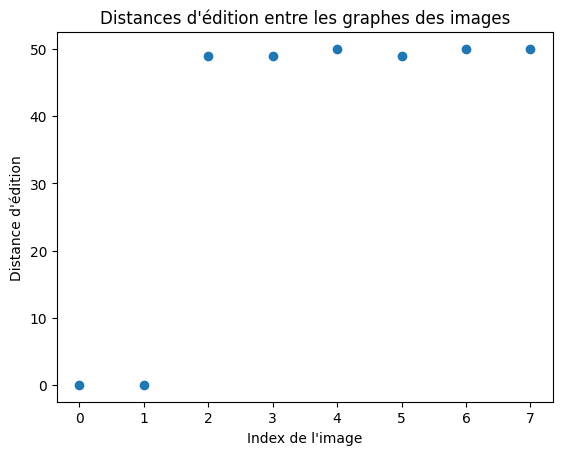

In [34]:
# A compléter ..
# ...
PtDesc = np.array([creer_dictionnaire(name, orb, False) for name in files])

nb=len(files)
Graphs=[createGraph(PtDesc) for i in range(nb)]
# A compléter ..
# ...

distances = []
for i in range(nb):
    distances.append([])
    for j in range(nb):
        if i == j:
            distances[i].append(0)
        else:
            cost = editDistFromAlign(Graphs[i], Graphs[j], PtDesc[i], PtDesc[j], costs)
            distances[i].append(cost)

print(distances)

plt.scatter(range(nb), distances[0], label='Distances d\'édition')
plt.title("Distances d'édition entre les graphes des images")
plt.xlabel("Index de l'image")
plt.ylabel("Distance d'édition")
plt.show()


#  Distance d'edition entre graphes

Nous allons dans cette partie lever la principale restriction du paragraphe précédent, à savoir que tous les sommets sont forcément appariés. En effet
forcer l’appariement de tous les sommets intégre dans la distance de mauvais appariements qui peuvent corrompre notre métrique entre images.
Cela signifit donc qu’il nous faudra définir un nouvel appariement qui inclu des opérations de suppression ou insertion de sommets.
Pour cela nous allons commencer par définir un nouvel ensemble de fonctions de coûts qui nous aideront à définir l’appariement.

### Appariement entre deux sommets

Il s’agit de définir la fonction *edit_cost_two_vertice* ui renvoie une estimation du coût (en terme de distance d’édition) de
l’appariement de deux sommets d’index index1 et index2 respectivement dans $G_1$ et $G_2$ . Ce coût est défini comme le coût d’appariement des deux sommets
(voir section 2.1) plus le coût de l’appariement optimal des arêtes incidentes. Nous allons pour cela construire une matrice n × n où n représente le max
des degrés des deux sommets. Plus précisément soit $n_1$ et $n_2$ les degrés des deux sommets avec $n =
max(n_1 , n_2 )$. On considère la matrice n × n C E définie par :

* $∀i ∈ \{1, . . . , n_1 \} \;∀j ∈ \{1, . . . , n_2 \}\; C_E (i, j) = C_e (e^i_1 , e^j_2 )$
* $∀i ∈ \{n_1 + 1, . . . , n\}\; ∀j ∈ \{1, . . . , n_2 \}\; C_E (i, j) = C_e (\epsilon, e^j_2 )$ = coût d’insertion d’arête
* $∀i ∈ \{1, . . . , n\}\; ∀j ∈ \{n_2 + 1, . . . , n\}\; C_E (i, j) = C_e (e ^i_1 ,\epsilon)$ = coût de suppression d’arête



où $C_e (e^i_1,e^j_2)$ représente le coût de substitution de deux arêtes.
Notez que si $n_1 = n_2$ seule la première équation s’applique, alors que si $n_1 < n_2$
seul les 2 premières équations s’appliquent et si $n_2 < n_1$ seul s’appliquent la
première et la troisième équation.Des exemples de matrices correspondant aux cas $n_1<n_2$ ou $n_1>n_2$ sont données ci
dessous:

* Cas $n_1<n_2$ :

$
C_E=\left(
    \begin{array}{llcccc}  
       &n_1 col.&&&n_2-n_1col\\\\
      C_e(e_1^1,e_2^1)&\dots&C_e(e_1^{n_1},e_2^1)&c_i&\dots&c_i\\  
      \vdots&\dots&\vdots&\vdots&\dots&\vdots\\
      C_e(e_1^1,e_2^{n_2})&\dots&C_e(e_1^{n_1},e_2^{n_2})&c_i&\dots&c_i\\        
    \end{array}
    \right)
$
* Cas $n_1>n_2$ :  
$
C_E=\left(
    \begin{array}{lllc}     
      &C_e(e_1^1,e_2^1)&\dots&C_e(e_1^{n_1},e_2^1)\\
   n_2~\text{lignes}&   \vdots&&\vdots\\
      &C_e(e_1^1,e_2^{n_2})&\dots&C_e(e_1^{n_1},e_2^{n_2})\\
      &c_d&\dots &c_d\\
n_1-n_2~\text{lignes}      &\vdots&&\vdots\\
      &c_d&\dots &c_d\\
    \end{array}\right)
$
où $c_i$ est le coût d'insertion et $c_d$ le coût de suppression d'arêtes.




L'application de l'algorithme Hongrois sur la matrice $C_E$ fournit un
coût d'appariement optimal noté $Cout(u_1,u_2)$ entre les ensembles
d'arêtes incidentes à $u_1$ et $u_2$ qui tient compte à la fois des
substitutions et des suppressions d'arêtes sur les deux voisinages.

Le coût de substitution de $u_1$ par $u_2$ est alors défini par :
$
C_n(u_1,u_2)=node_cost+Cout(u_1,u_2)
$
Le coût de suppression du sommet $u_1$ est défini par :
$
C_n(u_1,\epsilon)=c^v_d+2|V(u_1)|c^e_d
$
Ce qui correspond au coût de suppression de $u_1$ (le premier $c^v_d$)
et de l'ensemble de son voisinage (le second terme).

De même, le coût de suppression du sommet $u_2$ est défini par :
$
C_n(\epsilon,u_2)=c^v_i+2|V(u_2)|c^e_i
$

On évitera toutefois de calculer l’appariement optimal dans les cas triviaux
suivant :
1. $n_1 = 0, n_2\neq 0$. Dans ce cas les $n_2$ arêtes du second sommet sont
simplement insérées est le coût est égal à :
$C_n (u 1 , u 2 ) = node cost + n_2 ∗ c^e_i$

2. $n_2 = 0, n_1 \neq 0$. Dans ce cas, les $n_1$ arêtes du premier sommet doivent
être supprimées.
$C_n (u 1 , u 2 ) = node cost + n_1 ∗ c^e_d$

3. $n 1 = 0, n 2 = 0$ les deux sommets sont isolés. Dans ce cas le coût se réduit
au coût de substitution des deux sommets :
$C_n (u 1 , u 2 ) = node cost$

Notez que l’on simplifie ici le calcul. Quel type d’opération s’interdit on dû
fait de cette simplification ?

In [41]:
def coutSubstitutionNoeud(desc1, desc2, couts):
    # A compléter ..
    # ...
    cout = 0
    for key in desc1:
        if key in desc2:
            if desc1[key] != desc2[key]:
                cout += couts['nodeSubs']
        else:
            cout += couts['nodeDel']
    for key in desc2:
        if key not in desc1:
            cout += couts['nodeIns']
    return cout

def coutArete(G1, G2, n1, n2, v1, v2, i, j, couts):
    # A compléter ..
    # ...
    if i >= len(v1) and j < len(v2):
        return couts['edgeIns']
    if j >= len(v2) and i < len(v1):
        return couts['edgeDel']
    if i >= len(v1) and j >= len(v2):
        return 0

    edge1 = G1.get_edge_data(n1, v1[i])
    edge2 = G2.get_edge_data(n2, v2[j])

    if edge1 is None and edge2 is None:
        return 0
    if edge1 is None:
        return couts['edgeIns']
    if edge2 is None:
        return couts['edgeDel']

    w1 = edge1.get('weight')
    w2 = edge2.get('weight')

    return 0 if w1 == w2 else couts['edgeSubs']

def coutDeuxSommets(F1, F2, n1, n2, couts):
    # G1 = F1['graph']
    # G2 = F2['graph']
    G1 = F1
    G2 = F2
    v1 = list(nx.neighbors(G1, n1))
    v2 = list(nx.neighbors(G2, n2))
  
    card1 = len(v1)
    card2 = len(v2)
    
    n = max(card1, card2)
    
    nSub  = coutSubstitutionNoeud(F1['desc'][n1], F2['desc'][n2], couts)
    
    distances = [[coutArete(G1, G2, n1, n2, v1, v2, i, j, couts) for i in range(n)] for j in range(n)]

    cout = np.sum(distances)
    
    return nSub + cout

print(coutDeuxSommets(Graphs[0], Graphs[2], 2, 2, costs))


KeyError: 'desc'

Il s’agit de définir les deux fonctions :
*  editCostNodeRemoval
*  editCostNodeInsertion

qui renvoient respectivement le coût de la suppression et de l’insertion d’un
sommet. Ce coût est défini comme le coût de la suppression ou l’insertion
du sommet plus la somme des coûts des insertions ou suppressions des arêtes
incidentes au sommet.

In [42]:
def coutSuppressionNoeud(G, n, couts):
    # A compléter ..
    # ...
    cout = 0
    for i in range(n):
        cout += G.degree(i) * couts['edgeDel'] + couts['nodeDel']
    return cout


def coutInsertionNoeud(G, n, couts):
    # A compléter ..
    # ...
    cout = 0
    for i in range(n):
        cout += G.degree(i) * couts['edgeIns'] + couts['nodeIns']
    return cout
    

## Définition d’une nouvelle méthode d’appariement de sommets

Soient $n_1$ et $n_2$  taille des deux graphes. Pour définir l’appariement des
sommets du graphe nous allons définir une matrice de coûts de taille $n_1 + n_2$ constituée comme suit :

$
C=\left(
\begin{array}{c|cc}
&n_2&n_1\\
\hline
n_1&S&R\\
n_2&I&0\\
\end{array}
\right)
$

— La première matrice S, $n_1\times n_2$ code les coûts de substitution de sommets.
On l’initialise grâce à la fonction *editCostTwoVertice*.

— La seconde matrice R, $n_1 \times n_1$ code les suppressions de sommets de $G_1$ .
Il s’agit d’une matrice dont la diagonale est initialisée grâce à la fonction
*editCostNodeRemoval*. Les valeurs hors diagonale sont initialisées à
une grande valeur BIG VALUE pour interdire ces appariements.

— La troisième et dernière matrice I, $n_2 \times n_2$ code les insertions de sommets
de G 2 . Il s’agit d’une matrice dont la diagonale est initialisée grâce à
la fonction *editCostNodeInsertion*. Les valeurs hors diagonale sont
initialisées à une grande valeur BIG VALUE pour interdire ces appariements.

Définissez la fonction : *edit_distance* qui initialise la matrice comme définie ci-dessus puis calcule un appariement
optimal à partir de cette matrice. Cette fonction appelle ensuite la fonction
editDistFromAlign2 (à définir également voir section suivante) pour renvoyer le coût de la
distance d’édition associée à cet alignement.

## Modification du calcul du coût d’un alignement

Il s’agit ici de définir le code de la fonction editDistFromAlign (qui est une extension d’editDistFromAlign vue au TP2) pour prendre en compte
le fait que des sommets peuvent à présent être supprimés ou insérés. Plus précisément :

* Si $i < n_1$ est associé à $j < n 2$ (Bloc S) i est substitué à j comme
précédemment,
* Si $i < n_1$ est associé à $j \geq n_2$ (Bloc R) i est supprimé,
* Si $i \geq n_1$ est associé à $j < n_2$ (Bloc I) j est inséré,
* Si $i \geq n_1$ est associé à $j \geq n_2$ (Bloc 0), il s’agit d’une affectation entre
deux noeuds fictifs qui n’a aucun coût.

Comme précédemment, le coût de substitution de deux sommets est égal au
coût de substitution (contenu dans *costs*) fois la distance de Hamming entre
les deux sommets.

Les coûts d’insertion et de suppression de sommets sont simplement égaux
aux coûts contenus dans *costs*.

Notez que, contrairement à la fonction editDistFromAlign, ces coûts
d’appariement de sommets ne peuvent plus être déduits du coût de l’appariement
optimal.

Concernant les arêtes:

* il faut prendre en compte le fait qu’un sommet de $G_1$ peut être supprimé, auquel cas il faut ajouter au coût total la somme des coûts
de suppression des arêtes incidentes.
* Inversement, si on parcourt à présent le graphe $G_2$ . Si un sommet $f_i$ de $G_2$ est inséré, il faut ajouter au coût d’insertion du sommet le coût d’insertion de ses arêtes incidentes. De même, si le sommet i (substitué) et adjacent à j qui est supprimé, il faut
ajouter le coût de suppression de l’arête (i, j).

 * comme au TP2, si il existe deux sommets de $G_1$ i assigné $f_i$ et j à $f_j$ , il faut ajouter:
     * une substitution si $(i,j)\in E_1$ et $(f_i,f_j)\in E_2$
     * une suppression si $(i,j)\in E_1$ et $(f_i,f_j)\not\in E_2$
     * une insertion si $(i,j)\not\in E_1$ et $(f_i,f_j)\in E_2$
 
 
 Notez que les coût d'insertion/suppression d'arêtes liés à l'insertion/suppression de sommets peuvent être traités soit lors du traitement des arêtes, soit lors du traitement des sommets.

In [43]:
def areteOrdonnee(n, m):
    if n < m:
        return (n, m)
    return (m, n)

def distSommet(F1, F2, i, j, couts):
    # A compléter ..
    # ...
    if i >= len(F1['desc']) and j < len(F2['desc']):
        return coutInsertionNoeud(F2['graph'], j, couts)
    if j >= len(F2['desc']) and i < len(F1['desc']):
        return coutSuppressionNoeud(F1['graph'], i, couts)
    if i >= len(F1['desc']) and j >= len(F2['desc']):
        return 0

def distEditionDepuisAlignement(F1, F2, distances, coutsEdition):
    G1 = F1['graph']
    G2 = F2['graph']
    D1 = F1['desc']
    D2 = F2['desc']
    card1 = len(list(nx.nodes(G1)))
    card2 = len(list(nx.nodes(G2)))
    
    # A compléter ..
    # ...
    cout = 0
    for i in range(card1 + card2):
        for j in range(card1 + card2):
            cout += distances[i][j]
    
    return cout

def distanceEdition(F1, F2, couts):
    n1 = len(list(nx.nodes(F1['graph'])))
    n2 = len(list(nx.nodes(F2['graph'])))
    distances = [[distSommet(F1, F2, i, j, couts) for i in range(n1 + n2)] for j in range(n1 + n2)]
    
    return distEditionDepuisAlignement(F1, F2, distances, couts)


In [44]:
def affichage(distance, noms):
    nb = distance.shape[0]
    # A compléter ...
    # ...
    plt.matshow(distance)
    plt.xticks(ticks=np.arange(nb), labels=noms, rotation=90)
    plt.yticks(ticks=np.arange(nb), labels=noms)
    plt.colorbar(label='Distance d\'édition')
    plt.title("Distances d'édition entre les graphes des images")
    plt.show()

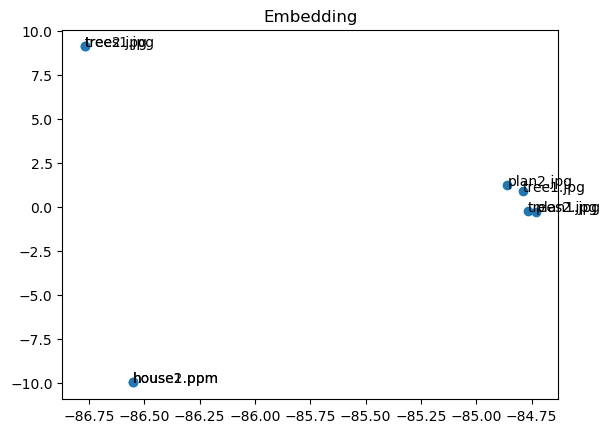

[[  0.           0.         361.11515062 377.81073754 368.66593614
  377.27074813 383.09964918 368.66593614]
 [  0.           0.         361.11515062 377.81073754 368.66593614
  377.27074813 383.09964918 368.66593614]
 [368.94568375 368.94568375   0.         345.66395166 379.2307864
  379.18783631 373.40287679 379.2307864 ]
 [375.93724323 375.93724323 350.58828294   0.         360.76381127
  383.51424345 361.76603627 360.76381127]
 [364.48462624 364.48462624 363.16762874 336.88634794   0.
  386.71523619 378.02041186   0.        ]
 [368.20640369 368.20640369 366.60816522 369.71889266 369.67768038
    0.         375.91608212 369.67768038]
 [385.94295326 385.94295326 345.655052   340.16226257 367.02885871
  391.51432582   0.         367.02885871]
 [364.48462624 364.48462624 363.16762874 336.88634794   0.
  386.71523619 378.02041186   0.        ]]


In [ ]:
nb=len(files)
distances=np.asarray([[distanceEdition(Graphs[i],Graphs[j],costs) for i in range(nb) ] for j in range(nb)])
noms=[os.path.basename(file) for file in files]
affichage(distances,noms)
print(distances)


# Diffusion maps

### Introduction

Pour de nombreux problèmes, les données collectées sont souvent de haute dimension, bruitées et non ordonnées, ce qui rend difficile la découverte de structures significatives. La carte de diffusion est une technique mathématique permettant d'analyser et d'organiser ces données en réduisant leur dimension, c'est-à-dire en identifiant une variété de dimension inférieure dans laquelle les points sont intégrés. La nouvelle représentation des points dans une telle structure doit préserver les relations importantes, telles que la distance mutuelle locale entre eux.

Contrairement à d'autres méthodes de réduction de dimension (telles que l'analyse en composantes principales, PCA), la carte de diffusion reste utile lorsque les données ont des formes non linéaires dans leur espace d'origine, car elle se concentre sur la découverte de la variété sous-jacente. De plus, cette technique est robuste face aux perturbations dues au bruit et peu coûteuse en termes de calcul.

### Cadre général

Étant donné un ensemble de données $X=\{x_1,...,x_n\} \in \mathbb{R}^p$, je décrirai cette technique et la construirai en suivant les étapes ci-dessous :

### 1. Définir un noyau et créer la matrice de noyau

>Considérons le noyau gaussien $$ k(x_{i},x_{j}) = \exp(-\frac{\lVert x_{i}-x_{j} \rVert^2}{\sigma_i \sigma_j}) $$
où $ \sigma_i=\lVert x_i-x_s \rVert^2 $ et $x_s$ est le $s$'ème voisin du point $x_i$. Définissons la matrice de noyau $K$, avec des entrées $ K_{ij}=k(x_{i},x_{j}) $. 

$\sigma_i$ est le paramètre d'échelle locale.

Notez que $K$ est une matrice symétrique $n*n$, dont les valeurs des entrées sont comprises entre 0 et 1, avec 0 sur la diagonale. $K_{ij}$ est faible si $x_i$ et $x_j$ sont éloignés dans l'espace des données, et élevé s'ils sont proches.

Ensuite, nous introduisons la connectivité entre deux points de données $x_i$ et $x_j$, qui est considérée comme la probabilité de passer de $x_i$ à $x_j$ en une étape d'une marche aléatoire. La relation entre la fonction de probabilité et la fonction de noyau est
$$ p(x,y)=\frac{k(x,y)}{\sum_{y\in X} k(x,y)} $$

Définissons la matrice de diffusion $P$, avec des entrées $ P_{ij}=p(x_{i},x_{j}) $. Notez que $P$ n'est pas symétrique et possède une séquence discrète de valeurs propres $1=\lambda_0 > \lvert \lambda_1 \rvert \geq \lvert \lambda_2 \rvert \geq \cdots$.

Soit $D$ une matrice diagonale $n*n$ telle que  
$$ 
D_{ii} = (\sum_{j=1}^n K_{ij})^{1/2}, 
$$  
alors $P = D^{-2}K$. En considérant une autre matrice $Q$, définie comme $ Q=DP D^{-1} $, nous avons :  
* $Q$ est symétrique.  
* $Q$ a les mêmes valeurs propres que $P$.  
* Les vecteurs propres de $Q$, notés $e_k$, sont multipliés par $D^{-1}$ et $D$ pour obtenir respectivement les vecteurs propres droits et gauches de $P$.

### 2. Normalisation par ligne de la matrice de noyau

Bien que $P$ soit la matrice souhaitée, il est plus pratique de calculer $Q$ :
>$$ Q=DP D^{-1}=D(D^{-2}K) D^{-1}=D^{-1}K D^{-1}. $$

En prenant des puissances de $P$, nous augmentons le nombre d'étapes parcourues, c'est-à-dire que $P_{ij}^{t}$ somme tous les chemins prenant $t$ étapes de $x_i$ à $x_j$, ce processus est appelé diffusion.

En augmentant la valeur de $t$, la probabilité de suivre un chemin le long de la structure géométrique sous-jacente de l'ensemble de données augmente, car le long de la structure géométrique, les points sont denses et donc fortement connectés, les chemins se forment le long de sauts courts et de haute probabilité.

Maintenant, nous définissons la distance de diffusion
$$ D_t(x_i,x_j)^2 = \sum_{u\in X}\lvert p_t(x_i,u)-p_t(u,x_j)\rvert^2 =
\sum_{k=1}^{n}\lvert P_{ik}^t-P_{kj}^t \rvert^2 $$
Elle est faible s'il existe de nombreux chemins de haute probabilité prenant $t$ étapes d'un point à un autre.

### 3. Trouver les vecteurs et valeurs propres de la matrice de diffusion

Comme mentionné précédemment,
>les valeurs propres de $P$ sont égales à celles de $Q$, et les vecteurs propres droits et gauches de $P$ sont :

$$ 
\psi_k=D^{-1} e_k , \phi_k=D e_k 
$$ 

respectivement.

### 4. Obtenir la carte de diffusion et traiter chaque ligne comme une coordonnée

Nous définissons une carte de diffusion $Y$, qui établit une correspondance entre les coordonnées des données et l'espace de diffusion, avec ses colonnes 
$$Y_i=
\begin{bmatrix}
p_t(x_i,x_1) \\
p_t(x_i,x_2) \\
\vdots       \\
p_t(x_i,x_n) \\
\end{bmatrix}
= \left[ \lambda_i^t \psi_i \right] = P_{i}^t.$$

Pour cette carte, $$ \lVert Y_i-Y_j \rVert_E^2 = \sum_{u\in X}\lvert p_t(x_i,u)-p_t(x_j,u)\rvert^2 = 
\sum_{k=1}^{n}\lvert P_{ik}^t-P_{kj}^t \rvert^2 = D_t(x_i,x_j)^2 $$
la distance de diffusion dans l'espace des données devient simplement la distance euclidienne dans l'espace de diffusion.

La réduction dimensionnelle est effectuée en négligeant certaines dimensions dans l'espace de diffusion, puisque les vecteurs propres gauches orthogonaux de $P$ forment une base pour l'espace de diffusion, les valeurs propres indiquent l'importance de chaque dimension, et sont classées par ordre décroissant comme mentionné précédemment.

## Implémentation

Implémenter les cartes de diffusion en suivant les étapes ci-dessus.

In [65]:
%matplotlib inline

In [47]:
# La fonction  get_K permet  d'obtenir la matrice de noyau gaussien.
def get_K(Dis, sigma):
    # A compléter ..
    # ...
    K = np.exp(-Dis**2 / (2 * sigma**2))
    
    return K    #Guassian kernel matrix

In [48]:
# La fonction  get_D permet d'obtenir la matrice diagonale $D$ 
def get_D(K):
    # A compléter ..
    # ...
    D = np.diag(np.sum(K, axis=1))
    
    
    return D


In [49]:
# La fonction  get_Q  permet d'obtenir la matrice $Q$ : Q=D^(-1)KD^(-1)
def get_Q(K, D):
    
    # A compléter ..
    # ...
    D_inv = np.linalg.inv(D)
    Q = D_inv @ K @ D_inv
    
    
    return Q    

In [50]:
# La fonction get_eig permet d'obtenir les valeurs propres et les vecteurs propres de la matrice de diffusion $P$. 
from scipy.sparse.linalg import svds

def get_eig(Q, D, c):
    # Calculer les c plus grandes valeurs singulières et vecteurs singuliers pour une matrice creuse
    # Étant donné que Q est une matrice symétrique réelle, les valeurs singulières et les valeurs propres non négatives coïncident
    U, S, Vt = svds(Q, k=c)

    # A compléter ..
    # ...
    
    # Inverser l'ordre des valeurs propres pour obtenir les plus grandes en premier
    # A compléter ..
    # ...
    eigenvals = S[::-1]
    
    # Inverser l'ordre des vecteurs propres
    # A compléter ..
    # ...
    U = U[:, ::-1]
    
    # Calculer les vecteurs propres droits de la matrice de diffusion
    # A compléter ..
    # ...
    D_inv = np.linalg.inv(D)
    psi = D_inv @ U
    
    return [psi, eigenvals]  # Valeurs propres non triviales et vecteurs propres droits de la matrice de diffusion

In [51]:
# La fonction  get_Y permet d'obtenir la carte de diffusion $Y$.
def get_Y(psi, eigenvals, c):
    list1=[]
    
    # A compléter ..
    # ...
    for i in range(c):
        list1.append(psi[:, i] * eigenvals[i])
        Y = np.column_stack(list1)
    return Y    #diffusion map
    

In [52]:
# La fonction  get_labels permet  d'obtenir les étiquettes des données via k-means.
from sklearn.cluster import KMeans

def get_labels(Y, clusters):

    # A compléter ..
    # ...
    kmeans = KMeans(n_clusters=clusters, random_state=0)
    labels = kmeans.fit_predict(Y)
    return labels

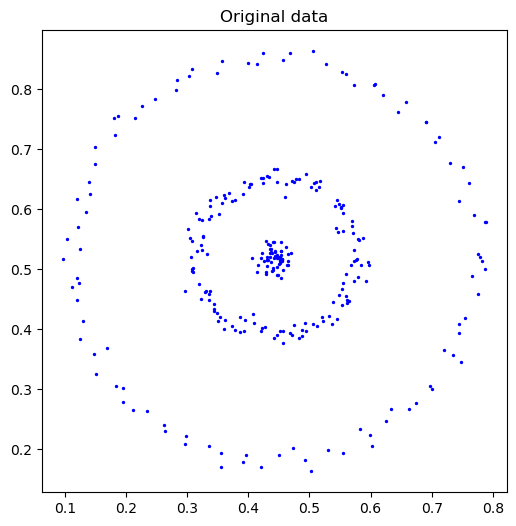

In [66]:
# Chargement des données
from scipy.io import loadmat

ori = loadmat('Data.mat')

n = len(ori['data'])       #number of points
p = len(ori['data'][0])    #dimension of points

for i in range(n):
    plt.scatter(ori['data'][i][0],ori['data'][i][1], s=2, c="blue")
plt.title("Original data")
plt.gcf().set_size_inches(6,6)
plt.show()


### 4. Définir les paramètres pour la carte de diffusion

D : matrice des distances euclidiennes entre les points de données dans $\mathbb{R}^p$.  
c : les $c$ plus grandes valeurs propres, c'est-à-dire la plus grande dimension que nous considérons.  
s : paramètre $s$ pour la construction de $\sigma$ personnalisée.  
sigma : une liste de paramètres d'échelle locale $\sigma_i$, nécessaire dans la fonction noyau gaussien.  
clusters : nombre de groupes.

In [53]:
from scipy.spatial.distance import squareform, pdist
Dis = squareform(pdist(ori['data']))
c = 3

s = 7
sigma=[]
Dis_sort = np.sort(Dis, axis=1)    # distance de chaque point à un autre triée par ordre croissant
for i in range(n): sigma.append( Dis_sort[i][s+1] )
    
clusters = 3

NameError: name 'ori' is not defined

In [56]:
# Calculer la carte de diffusion et les étiquettes des données

def diffusion(Dis, sigma, c, clusters):
    
    # A compléter ..
    # ...
    K = get_K(Dis, sigma)
    D = get_D(K)
    Q = get_Q(K, D)
    psi, eigenvals = get_eig(Q, D, c)
    Y = get_Y(psi, eigenvals, c)
    labels = get_labels(Y, clusters)
    
    return Y, labels

In [63]:
Y, labels = diffusion(Dis, sigma, c, clusters)

6. Afficher le résultat
##### 6.1 Afficher espace de diffusion 

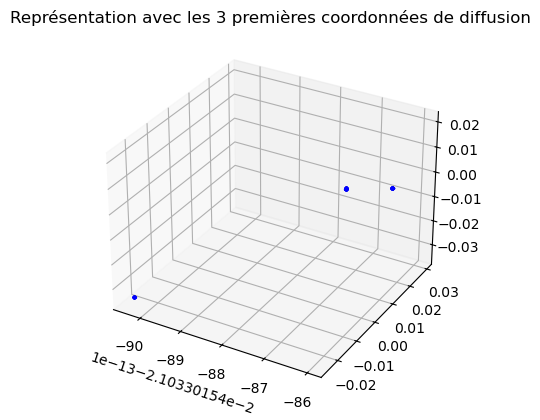

In [73]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i in range(n): 
    ax.scatter(Y[i][0], Y[i][1], Y[i][2], s=2, c='b')
ax.set_title('Représentation avec les 3 premières coordonnées de diffusion')
plt.show()


##### 6.2. Affichage des labels

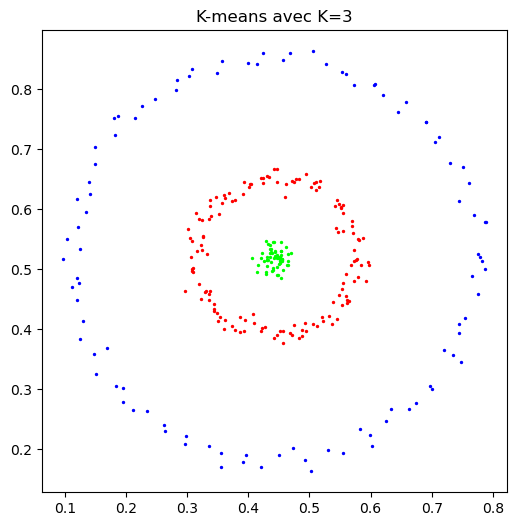

In [ ]:
    # A compléter ..
    # ...
plt.scatter(Y[:, 0], Y[:, 1], s=2, c=labels)
plt.title('k-means avec k = 3')
plt.gcf().set_size_inches(6,6)
plt.show()

## References

[1] R.R. Coifman and S. Lafon, Diffusion maps, Applied and computational harmonic analysis, 21:5–30, 2006  
[2] J. de la Porte, B. M. Herbst, W. Hereman and S. J. van der Walt., An Introduction to Diffusion Maps, Proceedings of the Nineteenth Annual Symposium of the Pattern Recognition Association of South Africa, 2008  
[3] L. Zelnik-Manor and P. Perona, Self-Tuning Spectral Clustering, Advances in Neural Information Processing Systems 17:1601-1608, 2005

# Classification d'images

Programme Python pour tester et comparer les performances de trois des techniques d'extraction de caractéristiques d'images les plus populaires :


<br>

    SIFT (Scale-Invariant Feature Transform) 
    SURF (Speeded Up Robust Features)
    HOG (Histogram of Oriented Gradients)

Le programme extrait d'abord les caractéristiques des images en utilisant ces 4 techniques, puis entraîne un Classificateur de Forêt Aléatoire et un Sigmoid à 2 couches et compare ensuite leur précision respective.


In [ ]:
# Import the required libraries

import os
import cv2
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from mahotas.features import surf as SURF
DATA = "data"
PATH = os.path.abspath('')
SAMPLES = os.listdir(f'{PATH}/{DATA}')

SIFT = cv2.SIFT_create(nfeatures=400)
HOG = cv2.HOGDescriptor()



In [66]:
def get_descriptors(sample, tech):
    # A compléter ..
    # ...
    if tech == 'sift':
        descriptors = SIFT.detectAndCompute(sample, None)[1]
    elif tech == 'hog': 
        descriptors = HOG.compute(sample)
    elif tech == 'surf':
        descriptors = SURF(sample)
    else:
        raise ValueError("Technique non reconnue. Choisissez parmi 'SIFT', 'HOG', ou 'SURF'.")
    return descriptors

In [ ]:
# Computing the descriptors

Data = {'sift': None, 'surf': None, 'hog': None}

for model in Data:
    data = []

    for sample in SAMPLES:
        # extraire les descripteurs de l'image sample avec le modèle model

        desc = get_descriptors(sample, model)
        # ajouter les descripteurs à la liste data

        # A compléter ..
        # ...
        data.append(desc)


    Data[model] = np.array(data)
    
    print("Données extraites avec succès pour", model.upper())

In [68]:
# Étiquettes pour le jeu de données

labels = np.zeros(606)

labels[0:202] = 0
labels[202:404] = 1
labels[404:606] = 2

In [ ]:
# Splitting DataSet into training (70%) and testing (30%) : train_test_split

DataSet = {'sift': {}, 'surf': {}, 'hog': {}}

# A compléter ..
# ...
for model in DataSet:
    X_train, X_test, y_train, y_test = train_test_split(Data[model], labels, test_size=0.3, random_state=42)
    DataSet[model]['train'] = (X_train, y_train)
    DataSet[model]['test'] = (X_test, y_test)

In [ ]:
# Initialisation des modèles : RandomForestClassifier et MLPClassifier

Models = {'sift': {}, 'surf': {}, 'hog': {}}

# A compléter ..
# ...
for model in Models:
    Models[model]['RandomForest'] = RandomForestClassifier(random_state=42)
    Models[model]['MLP'] = MLPClassifier(random_state=42)

In [ ]:
# Entraînement des RandomForestClassifiers :  Models[model]['RFC']

# A compléter ..
# ...
for model in Models:
    X_train, y_train = DataSet[model]['train']
    Models[model]['RandomForest'].fit(X_train, y_train)

In [ ]:
# Entraînement des réseaux de neurones artificiels (ANN):  Models[model]['ANN']

# A compléter ..
# ...
for model in Models:
    X_train, y_train = DataSet[model]['train']
    Models[model]['MLP'].fit(X_train, y_train)

In [ ]:
# Calcul de la précision pour tous les modèles

# A compléter ..
# ...
for model in Models:
    X_test, y_test = DataSet[model]['test']
    
    # Prédictions pour RandomForest
    y_pred_rf = Models[model]['RandomForest'].predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    
    # Prédictions pour MLP
    y_pred_mlp = Models[model]['MLP'].predict(X_test)
    accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
    
    print(f"Précision de RFC  ({model.upper()}): {accuracy_rf:.4f}")
    print(f"Précision de MLP  ({model.upper()}): {accuracy_mlp:.4f}\n")

Précision de RFC  (SIFT): 0.6648351648351648
Précision de ANN  (SIFT): 0.5659340659340659

Précision de RFC  (SURF): 0.6758241758241759
Précision de ANN  (SURF): 0.6043956043956044

Précision de RFC  (HOG): 0.5769230769230769
Précision de ANN  (HOG): 0.5714285714285714

